Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)


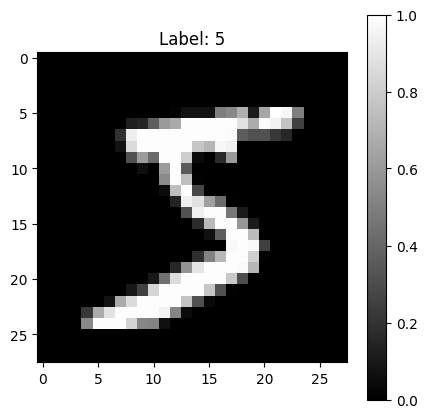

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9313 - loss: 0.2340 - val_accuracy: 0.9630 - val_loss: 0.1182
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9700 - loss: 0.0993 - val_accuracy: 0.9711 - val_loss: 0.0976
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9777 - loss: 0.0710 - val_accuracy: 0.9745 - val_loss: 0.0844
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9832 - loss: 0.0535 - val_accuracy: 0.9777 - val_loss: 0.0721
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9862 - loss: 0.0431 - val_accuracy: 0.9734 - val_loss: 0.0907


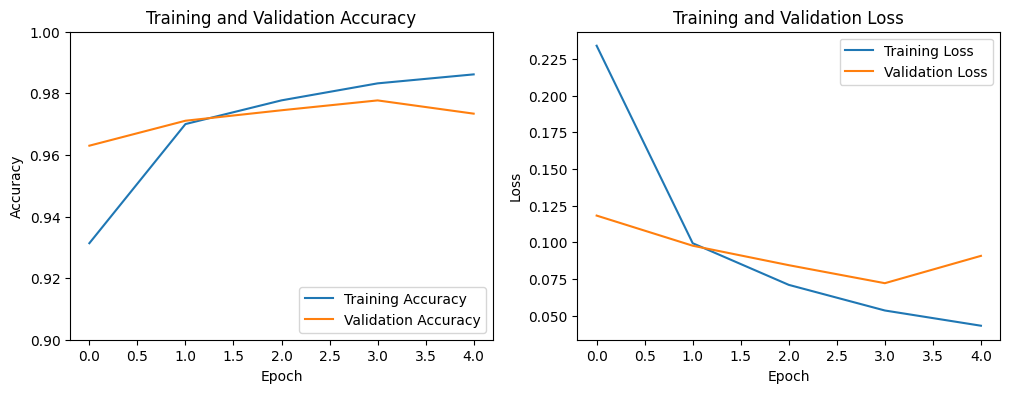

313/313 - 1s - 4ms/step - accuracy: 0.9734 - loss: 0.0907

Final Test Accuracy: 0.9734
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Model's predicted probabilities: [1.1148940e-09 4.3616897e-08 4.0972694e-07 2.2627511e-05 2.1357383e-09
 1.0080637e-07 9.0829270e-13 9.9997640e-01 7.9512752e-09 3.6977465e-07]
Predicted class: 7, True class: 7
Prediction is correct: True


In [10]:
# --- Import Libraries ---
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# --- Load and Prepare the MNIST Dataset ---
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values (0-255 → 0-1)
train_images = train_images / 255.0
test_images = test_images / 255.0

# Check data shapes
print("Training images shape:", train_images.shape)  # (60000, 28, 28)
print("Training labels shape:", train_labels.shape)  # (60000,)
print("Test images shape:", test_images.shape)        # (10000, 28, 28)

# Visualize one sample
plt.figure(figsize=(5, 5))
plt.imshow(train_images[0], cmap='gray')
plt.title(f"Label: {train_labels[0]}")
plt.colorbar()
plt.show()

# --- Build the Model ---
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),      # Input layer: 784 features
    layers.Dense(128, activation='relu'),      # Hidden layer 1
    layers.Dense(64, activation='relu'),       # Hidden layer 2
    layers.Dense(10, activation='softmax')     # Output layer: 10 classes
])

# View model summary
model.summary()

# --- Compile the Model ---
model.compile(
    optimizer='adam',  # Adaptive Moment Estimation (a variant of gradient descent)
    loss='sparse_categorical_crossentropy',  # for integer labels
    metrics=['accuracy']
)

# --- Train the Model ---
history = model.fit(
    train_images, train_labels,
    epochs=5,#5 passes through the training data
    validation_data=(test_images, test_labels)
)

# --- Visualize Training History ---
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.9, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

# --- Evaluate Model on Test Data ---
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

# --- Make a Prediction ---
predictions = model.predict(test_images)
first_image_prediction = predictions[0]

predicted_class = np.argmax(first_image_prediction)
true_class = test_labels[0]

print(f"Model's predicted probabilities: {first_image_prediction}")
print(f"Predicted class: {predicted_class}, True class: {true_class}")
print(f"Prediction is correct: {predicted_class == true_class}")


In [6]:
import sys
!{sys.executable} -m pip install matplotlib
